# 10 · Plotting

A handful of plots cover the workflow: look at the data, look at the fit, compare the models, look at
the posterior and what the data constrained, forecast what comes next, and check whether the
credible intervals mean what they say. Every plot is in magnitudes with brighter up (unless you ask
for flux), labels its time axis from the light curve's own reference, and returns its Axes.

**Needs:** the base install. `plot_corner` needs `corner`, which is a core dependency.

In [1]:
from pathlib import Path

# Works whether the notebook is run from notebooks/ or from the repository root.
ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "tests" / "data").is_dir())
AT2017GFO = ROOT / "tests" / "data" / "at2017gfo.csv"

import warnings
warnings.filterwarnings("ignore")           # keep the tutorial output readable

import numpy as np
import matplotlib.pyplot as plt
import whisper_cbpf as wp

print("whisper_cbpf", wp.__version__)

whisper_cbpf 0.2.0


In [2]:
lc = wp.load_lightcurve(AT2017GFO, redshift=0.0098)
g = lc.select_bands(["g"]).set_explosion_date(57982.529).select_time_window(0.0, 10.0)
if "upper_limit" in g.colnames:
    g = g.where(upper_limit=False)
print(lc.n_points, "points total,", g.n_points, "in the g-band window")

645 points total, 53 in the g-band window


## `plot_light_curve` — the data

`layout="report"` gives two panels, magnitude and flux, with every band overlaid; `layout="grid"`
gives one panel per band. Detections are circles, SNR < 3 points are up-triangles, upper limits are
down-triangles, and magnitude axes are inverted so brighter is up. The time axis names day 0:
"days since explosion" after `set_explosion_date`, or your own label after
`set_time_reference(mjd, "first detection")`.

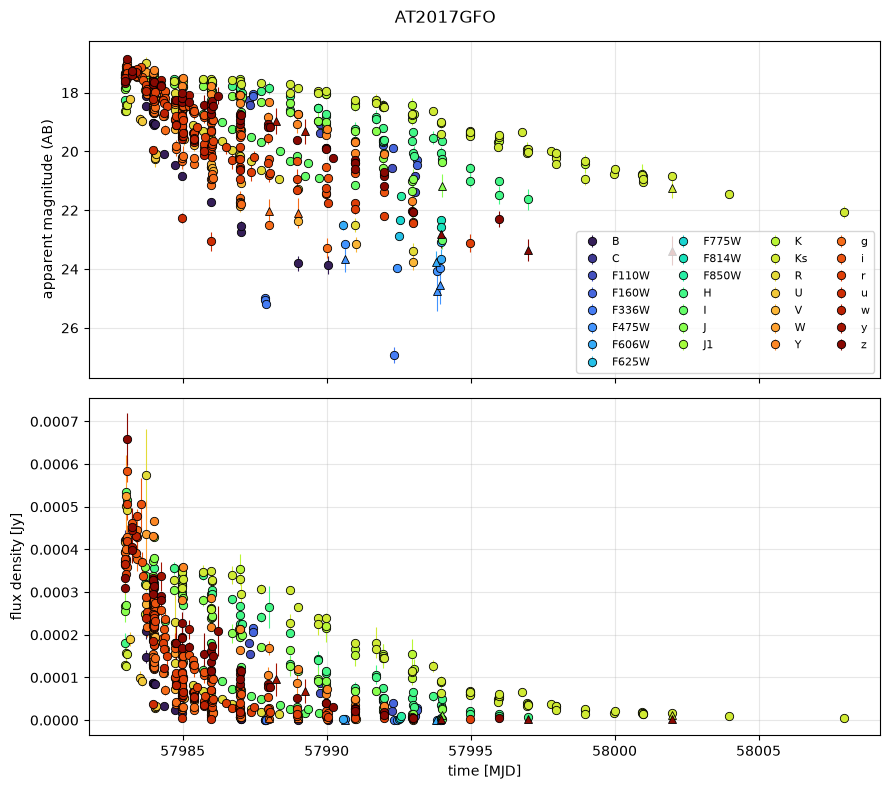

In [3]:
axes = wp.plot_light_curve(lc, layout="report", title="AT2017GFO")
plt.show()

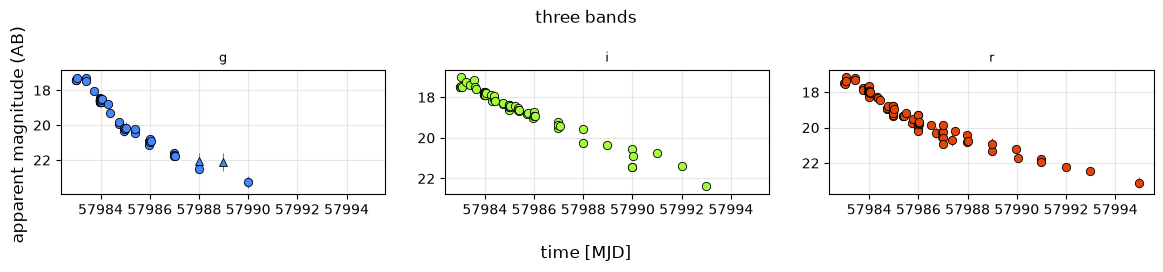

In [4]:
axes = wp.plot_light_curve(lc, layout="grid", bands=["g", "r", "i"], title="three bands")
plt.show()

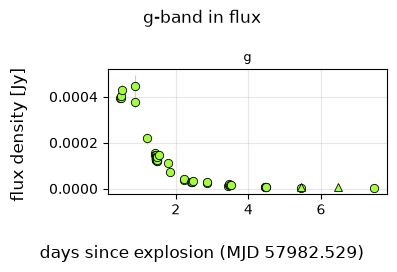

In [5]:
# In flux rather than magnitude.
axes = wp.plot_light_curve(g, quantity="flux", layout="grid", title="g-band in flux")
plt.show()

## `plot_ppc` — the fit against the data

A posterior predictive check draws from the posterior, forward-models each draw, and shows the
resulting 68 % and 95 % bands. This is the plot that catches a model which fits the peak and misses
the tail.

In [6]:
# Priors on the data's scale (notebook 5 explains why), and nested sampling, which converges on
# this light curve without a starting point (notebook 8). `compare` fits both models and ranks them.
LU, U = wp.LogUniform, wp.Uniform
prior_bazin = wp.Prior({"amplitude": LU(1e-5, 1e-2, name="amplitude"), "t0": U(-2.0, 2.0, name="t0"),
                        "tau_rise": LU(0.01, 5.0, name="tau_rise"),
                        "tau_fall": LU(0.1, 20.0, name="tau_fall")})
prior_grise = wp.Prior({"amplitude": LU(1e-5, 1e-2, name="amplitude"), "t0": U(0.0, 2.0, name="t0"),
                        "sigma_rise": LU(0.01, 5.0, name="sigma_rise"),
                        "tau_decay": LU(0.1, 20.0, name="tau_decay")})

cmp = wp.compare(g, ["bazin", "gaussian_rise"], sampler="nested", space="magnitude", nlive=200,
                 prior={"bazin": prior_bazin, "gaussian_rise": prior_grise}, seed=0)
r_bazin, r_grise = cmp.results["bazin"], cmp.results["gaussian_rise"]
print("bazin         AIC", round(r_bazin.aic, 1), "| converged:", r_bazin.info["converged"])
print("gaussian_rise AIC", round(r_grise.aic, 1), "| converged:", r_grise.info["converged"])

bazin         AIC 275.5 | converged: True
gaussian_rise AIC 275.5 | converged: True


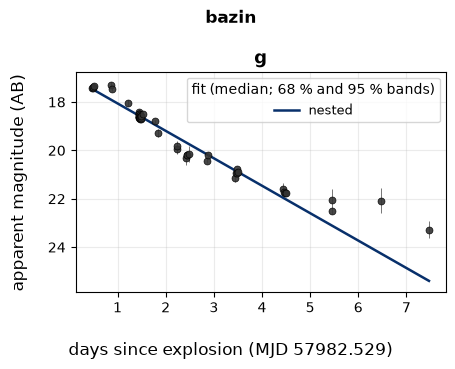

In [7]:
axes = wp.plot_ppc(r_bazin, g, model="bazin", n_draws=300, title="bazin")
plt.show()

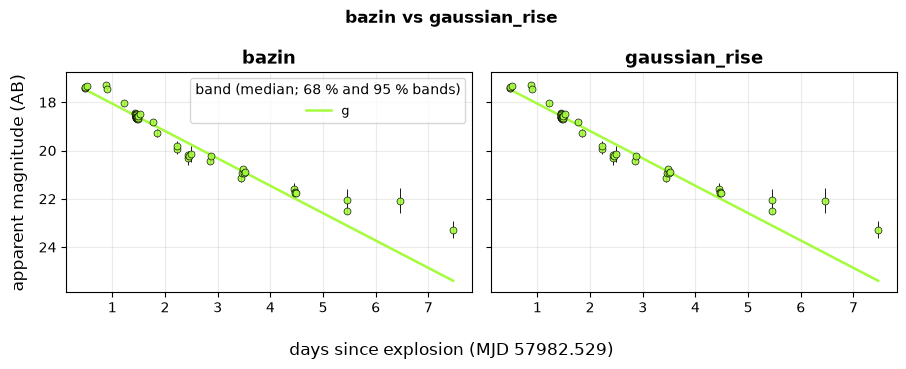

In [8]:
# Several results: pass a dict, whose keys label the panels. One panel per fit
# (panel_by="band" overlays them instead).
axes = wp.plot_ppc({"bazin": r_bazin, "gaussian_rise": r_grise}, g, n_draws=300,
                   title="bazin vs gaussian_rise")
plt.show()

Both models draw the same straight decline in magnitude, an exponential in flux, and both predict
the source fainter than observed after day 5: the g band fades more slowly late on than either
model can. The predictive band is narrower than the line here because the posterior is tight.

## `plot_models` — every model over the data

All models on one figure, one column per band, each with its posterior median and 68 % band, and the
residuals underneath so that a systematic misfit reads as a trend. Given a comparison, the models
come in rank order, labelled with their weights.

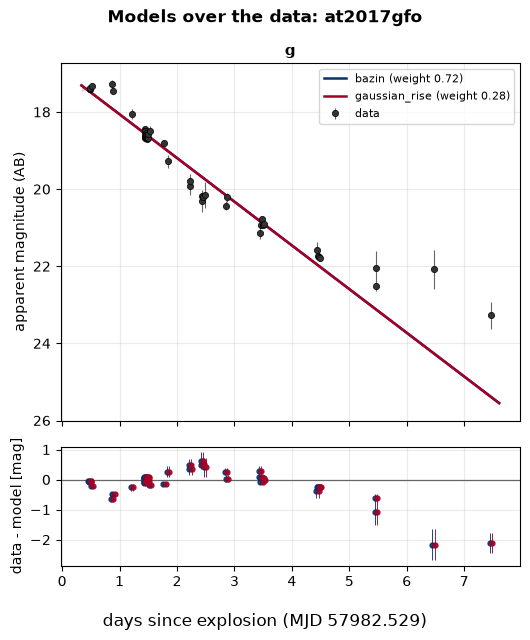

In [9]:
axes = wp.plot_models(cmp, g)
plt.show()

## `plot_model_comparison` — the ranking

Each model's weight, with its gap to the best in the ranking's own units (`ln Z` here) and the grade
of the preference.

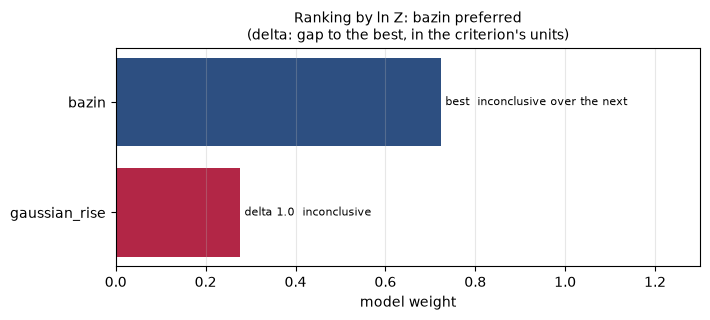

In [10]:
ax = wp.plot_model_comparison(cmp)
plt.show()

## `plot_corner` — the posterior

Note the **list**: `plot_corner` overlays several posteriors so you can see where two models, or two
samplers, disagree.

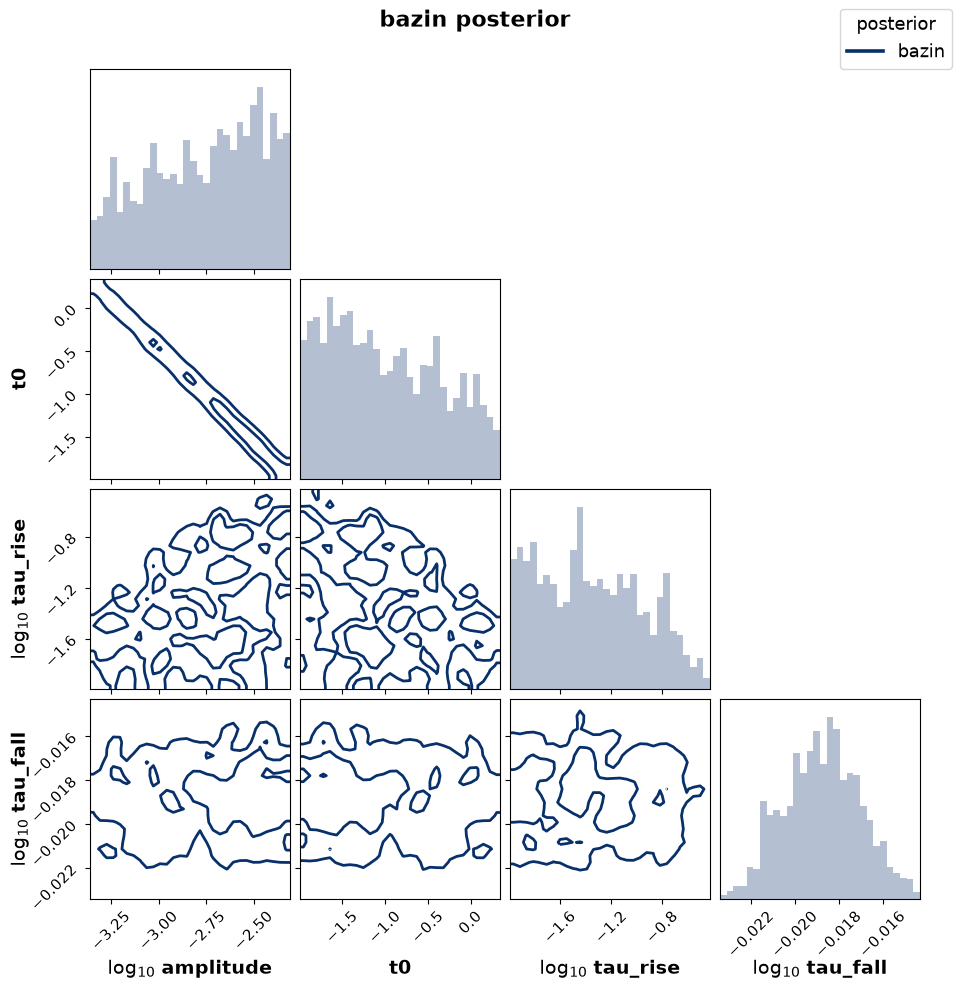

In [11]:
axes = wp.plot_corner([r_bazin], labels=["bazin"], title="bazin posterior")
plt.show()

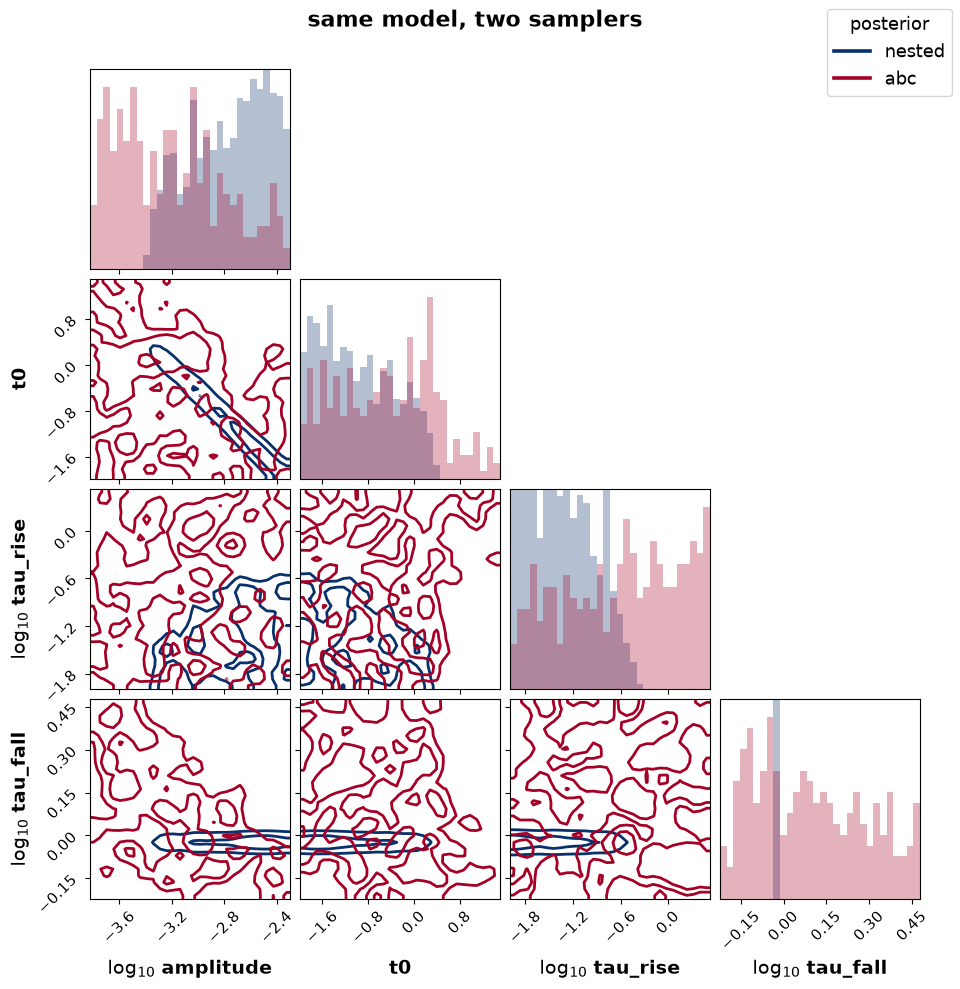

In [12]:
r_abc = wp.fit(g, "bazin", prior=prior_bazin, sampler="abc", space="magnitude",
               n_simulations=6000, quantile=0.05, seed=0)

axes = wp.plot_corner([r_bazin, r_abc], labels=["nested", "abc"],
                      title="same model, two samplers")
plt.show()

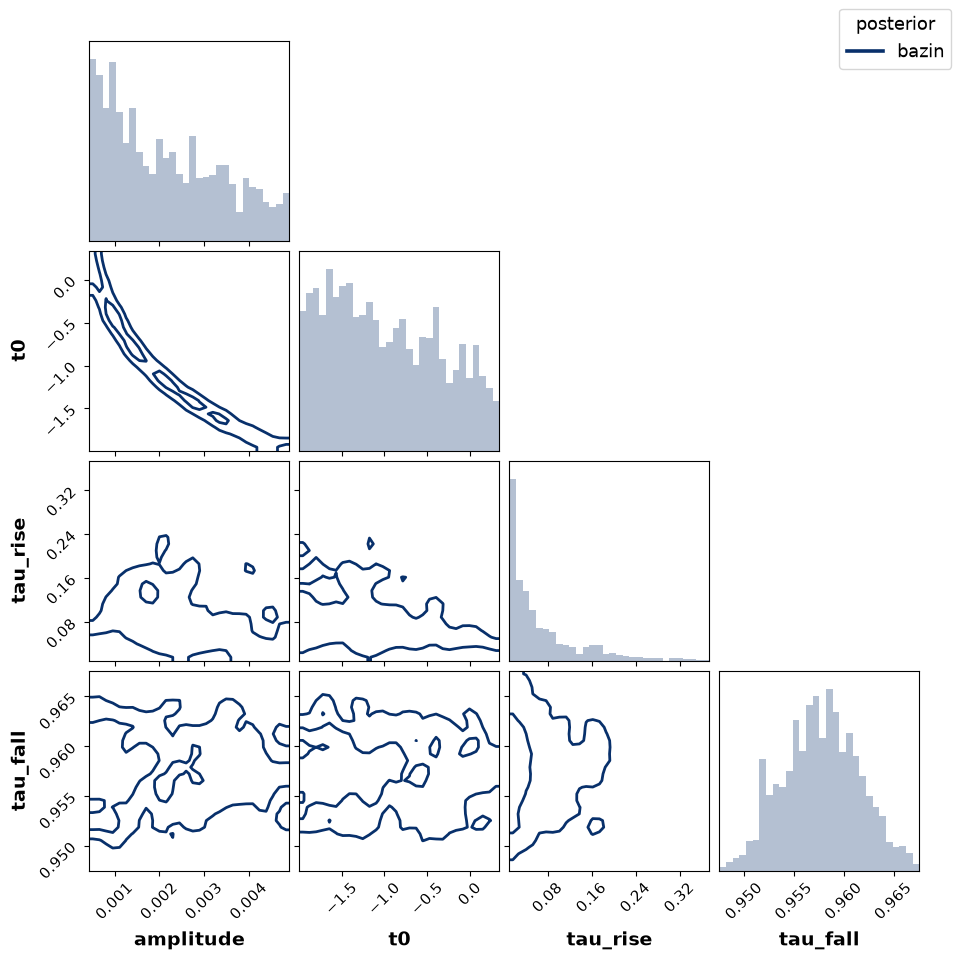

In [13]:
# By default (log_params="auto") every parameter with a LogUniform prior is drawn on a log axis, as
# above. Pass a list to choose them yourself, or [] for linear axes throughout.
axes = wp.plot_corner([r_bazin], labels=["bazin"], log_params=[])
plt.show()

## `plot_calibration` — are the intervals honest?

The coverage curve: for each nominal credible level, the fraction of data points the posterior
predictive interval actually contains. Below the diagonal means over-confident.

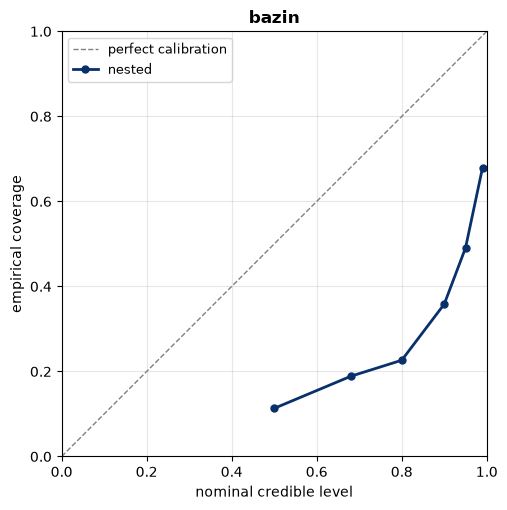

In [14]:
ax = wp.plot_calibration(r_bazin, g, model="bazin", n_draws=400, title="bazin")
plt.show()

## `plot_widths` — what the data constrained

Each parameter's posterior 68 % width over its prior 68 % width, in the prior's own coordinate
(log10 for a LogUniform). Near 1, the prior still decides; past the dashed line the parameter counts
as prior-dominated.

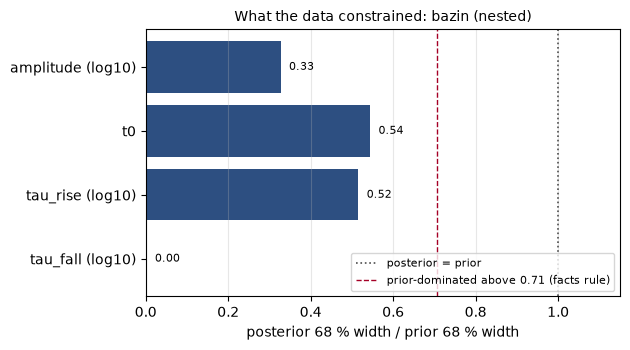

In [15]:
ax = wp.plot_widths(r_bazin)
plt.show()

## `plot_forecast` — what comes next

`wp.forecast` predicts each band on future epochs from the posterior; `plot_forecast` draws the
median with its 68 % and 95 % intervals, and marks epochs where most draws are too faint to see. The
forecast is the model's: the `plot_ppc` panels above show this g band already fading more slowly
than `bazin` after day 5.

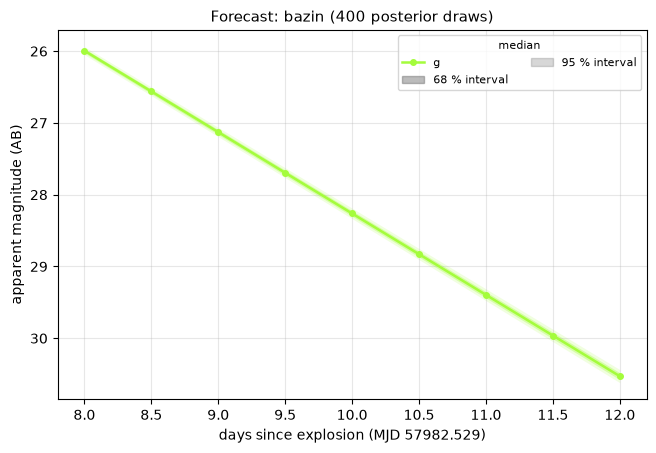

In [16]:
fc = wp.forecast(r_bazin, np.linspace(8.0, 12.0, 9), ["g"], lc=g)
ax = wp.plot_forecast(fc)
plt.show()

## Colours

`CORNER_PALETTE` is the sequence used when you overlay results, so a figure made here matches one
made elsewhere in the package.

['#08306b', '#a50026', '#006d2c', '#54278f', '#993404', '#252525']


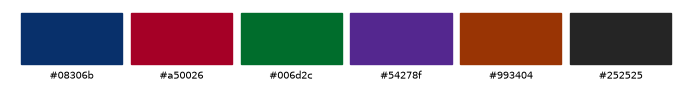

In [17]:
print(wp.CORNER_PALETTE)

fig, ax = plt.subplots(figsize=(7, 1.1))
for i, c in enumerate(wp.CORNER_PALETTE):
    ax.add_patch(plt.Rectangle((i, 0), 0.92, 1, color=c))
    ax.text(i + 0.46, -0.28, c, ha="center", fontsize=7)
ax.set_xlim(-0.1, len(wp.CORNER_PALETTE)); ax.set_ylim(-0.5, 1.05); ax.axis("off")
plt.tight_layout(); plt.show()

## Saving

Every plotting function takes `save=`, which writes the figure to that path; the call still returns
the Axes. For other `savefig` options, use the figure itself: `np.ravel(axes)[0].figure.savefig(...)`.

In [18]:
import tempfile, os
with tempfile.TemporaryDirectory() as tmp:
    path = os.path.join(tmp, "lightcurve.png")
    wp.plot_light_curve(g, save=path)
    print("wrote", os.path.basename(path), f"({os.path.getsize(path)} bytes)")
plt.close("all")

wrote lightcurve.png (62786 bytes)


## Where next

* [08 · Metrics and model comparison](08_metrics_and_comparison.ipynb) — the numbers behind these
  pictures.
* [09 · Validation and calibration](09_validation.ipynb) — the coverage curve, computed rather than
  drawn.